# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Sandi Suryo Nugroho|5054251020|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("WineQT.csv")

In [3]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('WineQT.csv')
data.head()
data.info()
data.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


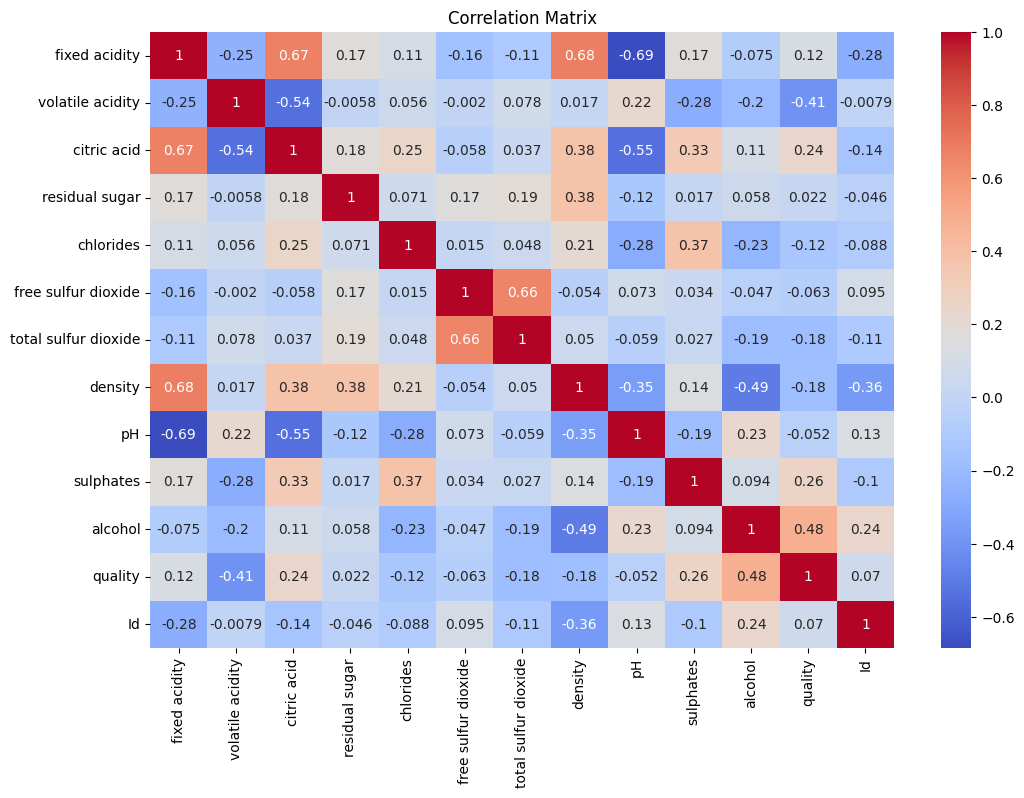

In [4]:
# Tampilkan Korelasi Matrix

plt.figure(figsize=(12, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

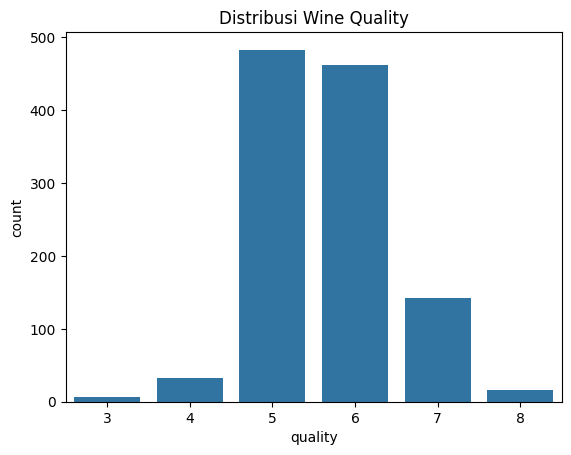

In [5]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

sns.countplot(x="quality", data=data)

plt.title("Distribusi Wine Quality")
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [6]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

print(data.isnull().sum())
print(f'Duplicate data: {data.duplicated().sum()}')
data = data.drop_duplicates()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
Duplicate data: 0


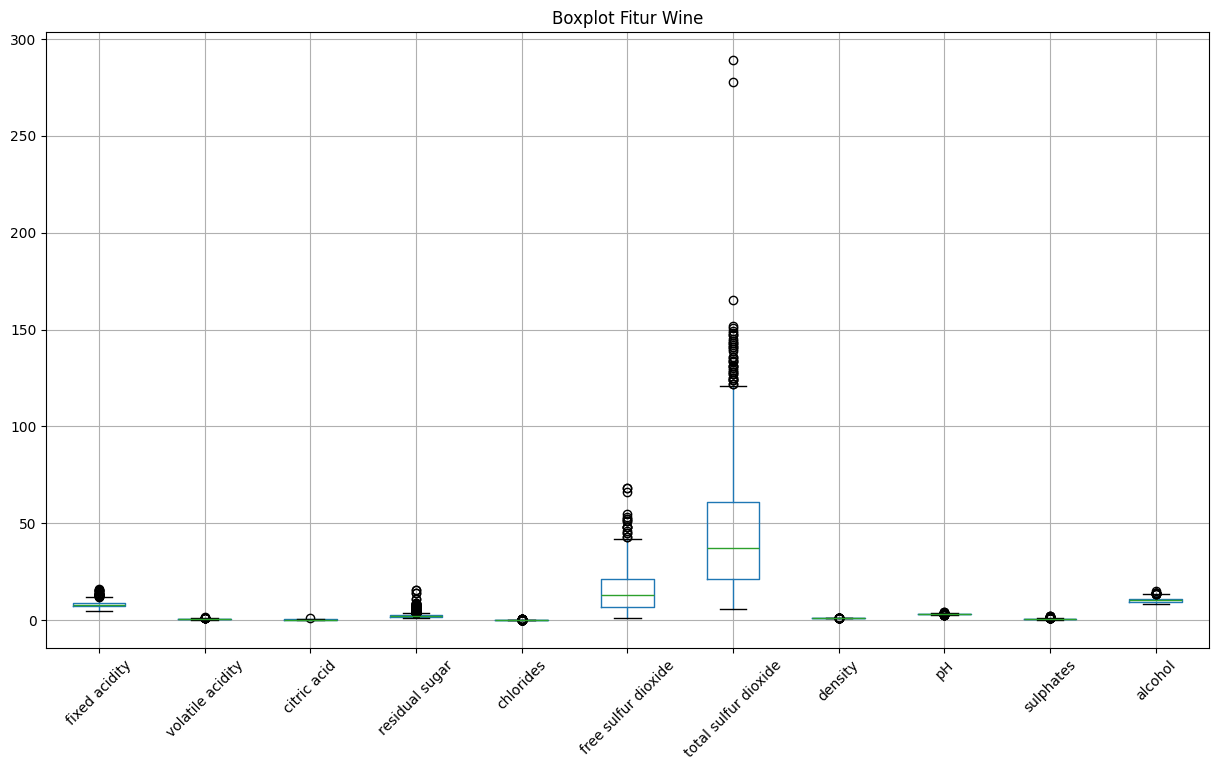

In [7]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)

plt.figure(figsize=(15, 8))

data.drop(columns=["quality", "Id"]).boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot Fitur Wine")
plt.show()

In [8]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

# pembagian data (80/20)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop(["quality", "Id"], axis=1)
y = data["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model KNN


In [9]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

metrics = ["euclidean", "manhattan"]
k_values = [1, 3, 5, 7, 9]

results = []

for metric in metrics:
    for k in k_values:

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train_scaled, y_train)

        train_pred = knn.predict(X_train_scaled)
        test_pred = knn.predict(X_test_scaled)

        results.append({
            "metric": metric,
            "k": k,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred)
        })

results_df = pd.DataFrame(results)

results_df

,metric,k,train_accuracy,test_accuracy
0,euclidean,1,1.000000,0.650655
1,euclidean,3,0.759300,0.606987
2,euclidean,5,0.683807,0.576419
3,euclidean,7,0.663020,0.593886
4,euclidean,9,0.640044,0.620087
5,manhattan,1,1.000000,0.659389
6,manhattan,3,0.746171,0.567686
7,manhattan,5,0.691466,0.585153
8,manhattan,7,0.664114,0.611354
9,manhattan,9,0.647702,0.659389


# 4. Evaluasi Model


Accuracy : 0.6593886462882096
Precision: 0.62218196855059
Recall   : 0.6593886462882096
F1 Score : 0.6389672293795265


c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


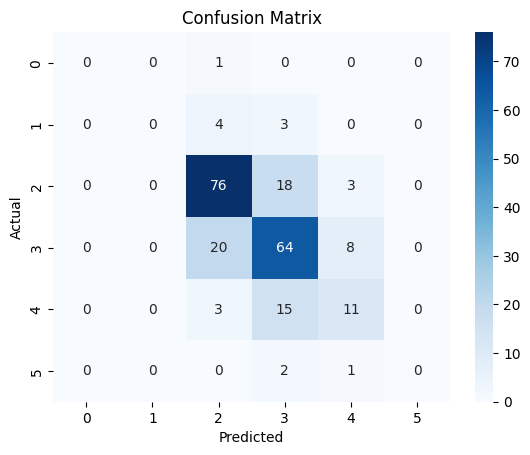

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.78      0.76        97
           6       0.63      0.70      0.66        92
           7       0.48      0.38      0.42        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.31      0.31      0.31       229
weighted avg       0.62      0.66      0.64       229



c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [13]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average="weighted"))
print("Recall   :", recall_score(y_test, test_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, test_pred, average="weighted"))

cm = confusion_matrix(y_test, test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, test_pred))

# 5. Analisis

**Perbandingan k dan metric jarak:**

| Observasi | Detail |
|---|---|
| k=1 selalu overfit | Train accuracy = 1.0 di kedua metric (wajar, karena k=1 cuma "menghafal" titik terdekat, termasuk noise) |
| Akurasi test terbaik | Manhattan k=9 dan k=1 sama-sama 0.659, tapi k=9 jauh lebih sehat karena train accuracy-nya (0.648) dekat dengan test accuracy, artinya model generalisasi, bukan menghafal |
| Euclidean vs Manhattan | Tidak ada pemenang jelas, selisihnya cuma 1-5 poin persen di tiap k, masih dalam rentang noise mengingat data cuma ~900 baris setelah split |
| Pola k terhadap overfitting | Semakin besar k, gap antara train dan test accuracy makin kecil (dari gap ~0.35 di k=1 turun ke ~0 di k=9), sesuai teori: k besar = keputusan lebih "smooth", makin tidak sensitif ke noise |

**Model terpilih untuk evaluasi lanjut: Manhattan, k=9** (accuracy 0.659, precision weighted 0.622, recall 0.659, F1 weighted 0.639).

**Confusion matrix dan classification report:**
- Model **tidak pernah memprediksi kelas 3, 4, atau 8 sama sekali** (kolom-kolom itu di confusion matrix, isinya nol semua). Precision, recall, dan F1 untuk ketiga kelas ini = 0.00.
- Model hanya bisa membedakan dengan baik kelas 5 dan 6 (recall 0.78 dan 0.70), dan lumayan untuk kelas 7 (recall 0.38).
- Kesalahan klasifikasi terkonsentrasi di kelas-kelas yang berdekatan (5↔6, 6↔7), masuk akal karena wine quality itu ordinal, wine dengan skor 5 dan 6 punya karakteristik kimia yang mirip.
- **Gap besar antara macro avg (0.31) dan weighted avg (0.64)** adalah bukti kuat bahwa performa model ini didorong sepenuhnya oleh kelas mayoritas (5 dan 6, total 189 dari 229 sampel test), sementara model sepenuhnya mengabaikan kelas minoritas.

**Penyebabnya: distribusi label sangat tidak seimbang.** Support di test set: kelas 3 (1), kelas 4 (7), kelas 8 (3), dengan sampel sesedikit itu, KNN nyaris tidak mungkin punya cukup tetangga sejenis untuk memprediksi kelas tersebut dengan benar.

# 6. Kesimpulan dan Saran

Model KNN terbaik pada eksperimen ini (Manhattan, k=9) mencapai akurasi ~66%, tapi angka itu menyesatkan jika dilihat sendiri, model ini praktis hanya berfungsi untuk memprediksi wine kualitas 5, 6, dan 7, dan gagal total di kelas ekstrem (3, 4, 8). Ini adalah kasus klasik **class imbalance**, bukan masalah pemilihan k atau metric jarak.

**Saran untuk eksperimen selanjutnya:**
- Tangani imbalance-nya langsung: coba oversampling (SMOTE) pada train set, atau gabungkan kelas ekstrem jadi kategori "low/medium/high quality" (misal 3-4 → low, 5-6 → medium, 7-8 → high) supaya distribusi lebih seimbang.
- Gunakan k-fold cross-validation, bukan satu kali train-test split. Dengan data sekecil ini (1143 baris), hasil akurasi bisa berubah cukup banyak tergantung split mana yang kebetulan terpilih.
- Bandingkan dengan model lain (Random Forest, SVM) yang biasanya lebih tahan terhadap imbalance dibanding KNN.
- Cek feature yang benar-benar informatif lewat correlation matrix, kalau ada fitur yang korelasinya sangat lemah ke quality, bisa dicoba dihapus untuk mengurangi noise di perhitungan jarak KNN.